<a href="https://colab.research.google.com/github/pachterlab/cellmender/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellmender import denoise_count_matrix
# except ImportError:
#     print("cellmender not found, installing...")
#     !pip install -U -q cellmender[analysis]

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import itertools
import yaml
import matplotlib.pyplot as plt
import anndata as ad
from collections import OrderedDict
import seaborn as sns
import scanpy as sc
from IPython.display import Image, display
# from cellbender.remove_background.downstream import anndata_from_h5
from cellmender import denoise_count_matrix
from cellmender.simulation import simulate_cells
import cellmender.utils as cm_utils
from cellmender.constants import CellBender_Fig2_to_Immune_All_High_celltype_mapping

cellmender_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellmender"

# import importlib
# import cellmender.celltype_ambient
# importlib.reload(cellmender.celltype_ambient)
# from cellmender.celltype_ambient import denoise_count_matrix

# import importlib
# import cellmender.utils.visualization_utils as visualization_utils
# importlib.reload(visualization_utils)
# from cellmender.utils.visualization_utils import plot_cross_species_histogram

# Compare CellBender vs. cellmender

Some datasets of use:
- pbmc8k: 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0
  - see run configuration on page 13 (bottom left) of the [Cellbender manuscript](https://doi.org/10.1038/s41592-023-01943-7)
- hgmm12k: Human-mouse mixture (CellBender Fig5): https://support.10xgenomics.com/single-cell-gene-expression/datasets/2.1.0/hgmm_12k

In [3]:
dataset_name = "simulation3_all_noise"  # options: pbmc8k, hgmm12k, simulation1_small_noise, simulation2_no_noise, simulation3_all_noise, custom
rerun_tools = True  # rerun tools if files don't exist OR if overwrite=True (else download from Box) - if True, requires docker
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
scar_env = "/home/jrich/miniconda3/envs/scar_gpu"
use_cuda = True  # for CellBender and scAR
threads = 8  # for cellmender and CellBender (if use_cuda=False)

yaml_file = os.path.join(cellmender_dir, "notebooks", "config", f"{dataset_name}.yaml")  # for a custom dataset, make a new yaml file in this location with the desired config - see example template at notebooks/config/custom.yaml

In [4]:
# load yaml
cfg = cm_utils.load_dataset_yaml(yaml_file)

# create directories for data, output
data_dir = os.path.join(cellmender_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellmender_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

# raw adata
adata_path_raw = f"{data_dir}/{cfg['adata_raw_file_name']}"
if not os.path.exists(adata_path_raw) and cfg["adata_raw_url"] is not None:
    !wget -O {adata_path_raw} {cfg["adata_raw_url"]}

# raw and filtered matrix tar files
matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
os.makedirs(matrix_tar_files_dir, exist_ok=True)

raw_tar_file_dir = f"{matrix_tar_files_dir}/{cfg['raw_tar_file_dir_suffix']}"
if not os.path.exists(raw_tar_file_dir) and cfg["raw_tar_url"] is not None and rerun_tools:
    raw_tar_path = os.path.join(matrix_tar_files_dir, cfg["raw_tar_file_name"])
    !wget -O {raw_tar_path} {cfg["raw_tar_url"]}
    !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}

filtered_tar_file_dir = f"{matrix_tar_files_dir}/{cfg['filtered_tar_file_dir_suffix']}"
if not os.path.exists(filtered_tar_file_dir) and cfg["filtered_tar_url"] is not None and rerun_tools:
    filtered_tar_path = os.path.join(matrix_tar_files_dir, cfg["filtered_tar_file_name"])
    !wget -O {filtered_tar_path} {cfg["filtered_tar_url"]}
    !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}

sequencing_technology = cfg["sequencing_technology"]

# set file paths for tools
adata_path_cellmender = f"{data_dir}/{cfg['adata_path_cellmender_name']}"
cellmender_log_file = os.path.join(data_dir, "cellmender.log")

adata_path_cellbender = f"{data_dir}/{cfg['adata_path_cellbender_name']}"
adata_path_cellbender_filtered = adata_path_cellbender.replace(".h5", "_filtered.h5")
cellbender_ckpt = os.path.join(data_dir, "cellbender_ckpt.tar.gz")

soupx_out_prefix = f"{data_dir}/{cfg['soupx_out_prefix_name']}"
adata_soupx_obs_csv = f"{data_dir}/{dataset_name}_soupx_obs.csv"

decontx_out_prefix = f"{data_dir}/{cfg['decontx_out_prefix_name']}"

adata_path_scar = f"{data_dir}/{cfg['adata_path_scar_name']}"


if dataset_name == "hgmm12k":    
    matrix_tar_files_dir = os.path.join(matrix_tar_files_dir, "combined")
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "combined")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "combined")
    # # check if raw_tar_file_dir is empty or doesn't exist
    # if rerun_tools and (not os.path.exists(raw_tar_file_dir) or len(os.listdir(raw_tar_file_dir)) == 0) or (not os.path.exists(filtered_tar_file_dir) or len(os.listdir(filtered_tar_file_dir)) == 0):
    adata_raw = cm_utils.load_adata(adata_path_raw, verbose=verbose)
    umi_cutoff = cm_utils.knee_plot(adata_raw, expected_cells=cfg["expected_cells"], show=False)
    adata_raw = cm_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
    paths = cm_utils.write_10x_like(adata_raw, matrix_tar_files_dir, gzip_output=(True if sequencing_technology == "10XV3" else False), is_empty_col="is_empty", cluster_col=None, genome="combined", write_raw=True, write_filtered=True)
    
    # # soupx inputs
    # matrix_tar_files_dir
    adata_soupx_obs_csv = paths["clusters"]
    # soupx_out_prefix

    # # decontx inputs
    raw_tar_file_dir = paths["raw"]
    filtered_tar_file_dir = paths["filtered"]
    sequencing_technology = paths["technology"]
    # decontx_out_prefix

if dataset_name.startswith("simulation"):
    # load simulation config
    with open(yaml_file, "r") as f:
        config = yaml.safe_load(f)

    # simulate data
    if not os.path.exists(adata_path_raw) or overwrite:
        adata_raw = simulate_cells(
            G=config["G"],
            k=config["k"],
            markers_per_type=config["markers_per_type"],
            marker_boost=config["marker_boost"],
            type_proportions=config["type_proportions"],
            empty_prob=config["empty_prob"],
            alpha=config["alpha"],
            expected_cell_size=config["expected_cell_size"],
            rng_seed=42,
        )
        adata_raw.write_h5ad(adata_path_raw)
    else:
        adata_raw = cm_utils.load_adata(adata_path_raw, verbose=verbose)

    paths = cm_utils.write_10x_like(adata_raw, matrix_tar_files_dir, gzip_output=(True if sequencing_technology == "10XV3" else False), is_empty_col="is_empty", cluster_col=None, write_raw=True, write_filtered=True)

    # # soupx inputs
    # matrix_tar_files_dir
    adata_soupx_obs_csv = paths["clusters"]
    # soupx_out_prefix

    # # decontx inputs
    raw_tar_file_dir = paths["raw"]
    filtered_tar_file_dir = paths["filtered"]
    sequencing_technology = paths["technology"]
    # decontx_out_prefix


# lay out parameters
model_pkl = cfg["model_pkl"]
cellmender_max_iter = cfg["cellmender_max_iter"]
cellmender_beta = cfg["cellmender_beta"]
cellmender_init_alpha = cfg["cellmender_init_alpha"]
cellbender_epochs = cfg["cellbender_epochs"]
cellbender_fpr = cfg["cellbender_fpr"]
cellbender_zdim = cfg["cellbender_zdim"]
cellbender_expected_cells = cfg["cellbender_expected_cells"]
cellbender_total_droplets = cfg["cellbender_total_droplets"]
scar_epochs = cfg["scar_epochs"]
scar_prob = cfg["scar_prob"]
expected_cells = cfg["expected_cells"]
cs_empty_threshold = cfg["cs_empty_threshold"]
min_genes = cfg["min_genes"]
min_cells = cfg["min_cells"]
umi_top_percentile_to_remove = cfg["umi_top_percentile_to_remove"]
fraction_doublet = cfg["fraction_doublet"]
unique_genes_top_percentile_to_remove = cfg["unique_genes_top_percentile_to_remove"]
mt_gene_percentile_to_remove = cfg["mt_gene_percentile_to_remove"]
max_mt_percentage = cfg["max_mt_percentage"]
n_top_genes = cfg["n_top_genes"]
n_pcs = cfg["n_pcs"]
n_neighbors = cfg["n_neighbors"]
leiden_resolution = cfg["leiden_resolution"]
marker_genes = cfg["marker_genes"]

cellmender_matrix_url = cfg["cellmender_matrix_url"]
cellbender_matrix_url = cfg["cellbender_matrix_url"]
cellbender_matrix_filtered_url = cfg["cellbender_matrix_filtered_url"]
cellbender_ckpt_url = cfg["cellbender_ckpt_url"]
soupx_matrix_url = cfg["soupx_matrix_url"]
decontx_matrix_url = cfg["decontx_matrix_url"]
scar_matrix_url = cfg["scar_matrix_url"]

## Raw

In [5]:
adata_raw = cm_utils.load_adata(adata_path_raw, verbose=verbose)
adata_raw.var_names_make_unique()

02:01:17 - INFO - Loading adata from '/home/jrich/Desktop/cellmender/notebooks/data/simulation3_all_noise/adata_raw.h5ad'


## Knee plot - use this output to estimate cs_empty_threshold

UMI cutoff for expected cells (200): 345.00


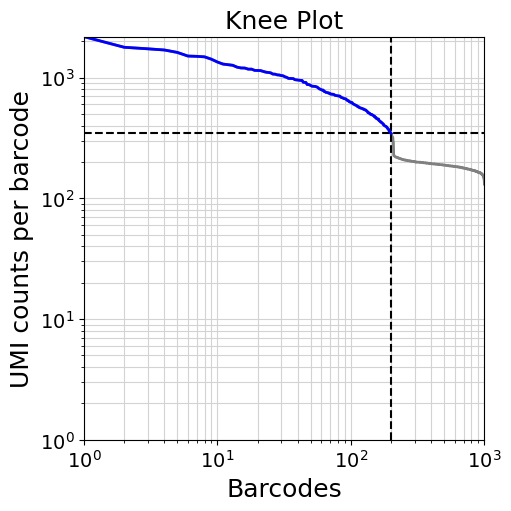

In [6]:
umi_cutoff = cm_utils.knee_plot(adata_raw, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))

In [7]:
# umi_cutoff = 0  #!!! optionally update from knee plot
adata_raw = cm_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
adata_raw.var['empty_counts'] = np.array(adata_raw.X[adata_raw.obs['is_empty'].values, :].sum(axis=0)).flatten()

In [8]:
if dataset_name == "hgmm12k" and 'celltype' not in adata_raw.obs:
    adata_raw.obs['hg19_total_counts'] = np.asarray(adata_raw[:, adata_raw.var['genome'] == 'hg19'].X.sum(axis=1)).ravel()
    adata_raw.obs['mm10_total_counts'] = np.asarray(adata_raw[:, adata_raw.var['genome'] == 'mm10'].X.sum(axis=1)).ravel()
    adata_raw.obs['genome'] = np.where(adata_raw.obs['hg19_total_counts'] >= adata_raw.obs['mm10_total_counts'], 'hg19', 'mm10')  # predict genome
    adata_raw.obs['celltype'] = adata_raw.obs['genome']

    adata_raw = cm_utils.detect_doublets_human_mouse(adata_raw, fraction_doublet=fraction_doublet, plot_empty=False, umi_cutoff=umi_cutoff, expected_cells=expected_cells, out_path=os.path.join(out_dir, "hgmm12k_doublet_detection.png"), show=False)

Gene_1482: 297
Gene_1453: 290
Gene_1178: 271
Gene_47: 262
Gene_751: 255
Gene_1380: 237
Gene_896: 237
Gene_1790: 230
Gene_361: 230
Gene_1695: 224


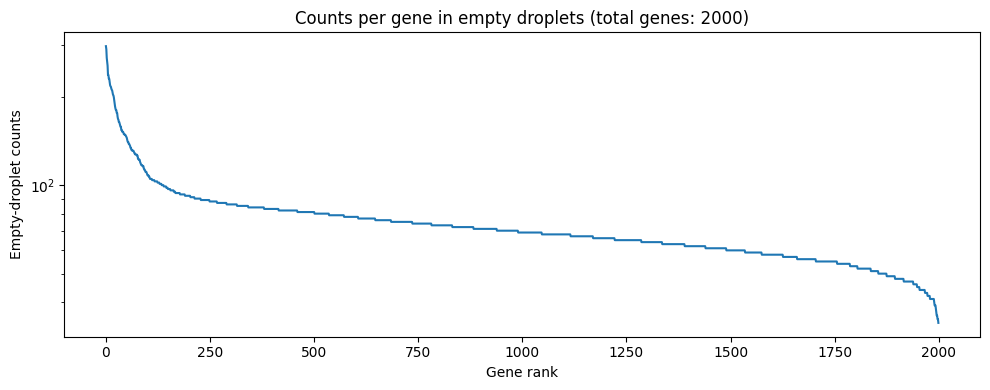

In [9]:
cm_utils.plot_empty_gene_counts(adata_raw, out_path=os.path.join(out_dir, "empty_droplet_gene_counts.png"))
cm_utils.print_top_empty_genes(adata_raw, top_n=10, out_path=os.path.join(out_dir, "empty_genes.csv"))

## cellmender

In [10]:
%%time
if not os.path.exists(adata_path_cellmender) or overwrite:
    adata = adata_raw.copy()
    if "celltype" not in adata.obs.columns:
        adata = cm_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)
    _ = denoise_count_matrix(adata, adata_out=adata_path_cellmender, beta=cellmender_beta, freeze_ambient_profile=True, init_alpha = cellmender_init_alpha, max_iter=cellmender_max_iter, empty_droplet_method="threshold", expected_cells=expected_cells, threads=threads, verbose=verbose, log_file=cellmender_log_file)

02:01:19 - INFO - Inferring celltype profiles.
02:01:19 - DEBUG - Number of parameters in the cellmender model: 46,001 beta: 1, gamma_type: 4,600, p_k: 46,000)
02:01:19 - INFO - Inferring the gene ambient profile from empty droplets.
02:01:19 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
02:01:19 - INFO - Performing Sparse EM with 8 Numba thread(s)


Logging to /home/jrich/Desktop/cellmender/notebooks/data/simulation3_all_noise/cellmender.log


02:01:21 - INFO - EM Iter   1: ll=-2161354.899 min_alpha=0.5267 mean_alpha=0.8055 median_alpha=0.8196 max_alpha=0.8638 beta=0.096223
02:01:21 - INFO - EM Iter   2: ll=-2137612.323 min_alpha=0.1868 mean_alpha=0.6947 median_alpha=0.7241 max_alpha=0.8411 beta=0.090158
02:01:21 - INFO - EM Iter   3: ll=-2126255.962 min_alpha=0.0447 mean_alpha=0.6140 median_alpha=0.6522 max_alpha=0.8348 beta=0.084658
02:01:21 - INFO - EM Iter   4: ll=-2120035.373 min_alpha=0.0083 mean_alpha=0.5523 median_alpha=0.5935 max_alpha=0.8302 beta=0.079557
02:01:21 - INFO - EM Iter   5: ll=-2116113.164 min_alpha=0.0014 mean_alpha=0.5046 median_alpha=0.5467 max_alpha=0.8272 beta=0.074825
02:01:21 - INFO - EM Iter   6: ll=-2113465.877 min_alpha=0.0002 mean_alpha=0.4671 median_alpha=0.5104 max_alpha=0.8256 beta=0.070411
02:01:21 - INFO - EM Iter   7: ll=-2111590.308 min_alpha=0.0000 mean_alpha=0.4372 median_alpha=0.4832 max_alpha=0.8248 beta=0.066274
02:01:21 - INFO - EM Iter   8: ll=-2110217.861 min_alpha=0.0000 mean_

CPU times: user 17.5 s, sys: 2.45 s, total: 20 s
Wall time: 7.68 s


In [11]:
adata_cellmender = ad.read_h5ad(adata_path_cellmender)
adata_cellmender = adata_cellmender[~adata_cellmender.obs["is_empty"]].copy()
adata_cellmender.var_names_make_unique()
print(f"Counts are less than or equal check for CellMender: {cm_utils.check_counts_less_equal(adata_raw, adata_cellmender)}")

Counts are less than or equal check for CellMender: True


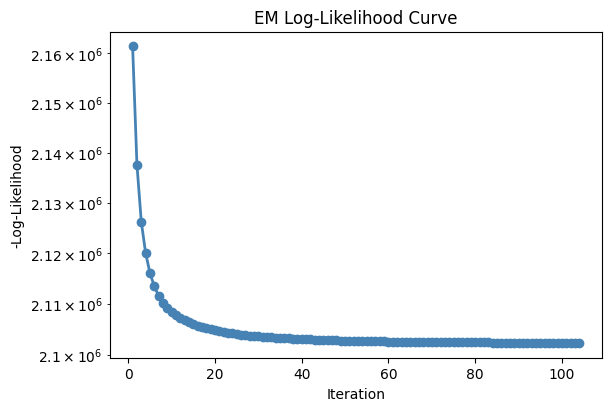

LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

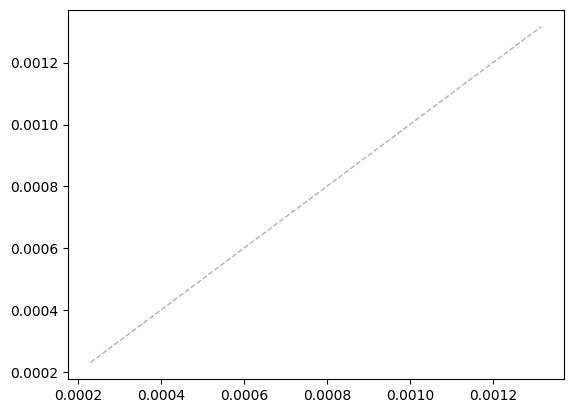

In [12]:
# plot CellMender likelihood over epochs
if os.path.exists(cellmender_log_file):
    cm_utils.plot_cellmender_likelihood_over_epochs(log_path=cellmender_log_file, show=True)

# plot ambient_hat vs empty fraction
cm_utils.plot_ambient_hat_vs_empty_fraction(adata_raw, adata_cellmender, remove_zeroes=True, lower_quantile_removed=None, upper_quantile_removed=0.99, out_path=os.path.join(out_dir, "cellmender_ambient_hat_vs_empty_fraction.png"))

# plot knee plot colored by alpha_hat
adata_denoised = adata_cellmender.copy()
adata_denoised.layers["denoised"] = adata_denoised.X.copy()
adata_denoised.X = adata_denoised.layers["raw"].copy()
cm_utils.knee_plot(adata_denoised, expected_cells=expected_cells, color_column="alpha_hat")
cm_utils.knee_plot(adata_denoised[~adata_denoised.obs["is_empty"]], expected_cells=expected_cells, color_column="alpha_hat")
adata_denoised.obs["total_counts_raw"] = np.ravel(adata_denoised.layers["raw"].sum(axis=1))
adata_denoised.obs["total_counts_denoised"] = np.ravel(adata_denoised.layers["denoised"].sum(axis=1))
adata_denoised.obs.loc[~adata_denoised.obs["is_empty"]].head(50)

## CellBender (v0.3.0)

In [13]:
%%time
if not os.path.exists(adata_path_cellbender) or overwrite:
     if rerun_tools:
          runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
          expected_cells_line = f"--expected-cells {cellbender_expected_cells}" if cellbender_expected_cells is not None else ""
          total_droplets_line = f"--total-droplets-included {cellbender_total_droplets}" if cellbender_total_droplets is not None else ""
          gpus = "--gpus all" if use_cuda else ""
          input_path = adata_path_raw.replace(f"{cellmender_dir}/notebooks/data", "/data")
          output_dir = os.path.dirname(adata_path_cellbender).replace(f"{cellmender_dir}/notebooks/data", "/data")
          output_path = adata_path_cellbender.replace(f"{cellmender_dir}/notebooks/data", "/data")
          ckpt_out_path = cellbender_ckpt.replace(f"{cellmender_dir}/notebooks/data", "/data")
          # note that if I echo this, then I need to add extra quotes around the bash -c command to copy-paste it
          !docker run --rm {gpus} -v {cellmender_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
               bash -c 'mkdir -p {output_dir} && cellbender remove-background \
               --input {input_path} {expected_cells_line} {total_droplets_line} \
               --output {output_path} \
               --epochs {cellbender_epochs} \
               --fpr {cellbender_fpr} \
               --z-dim {cellbender_zdim} \
               --model full \
               {runtime} && \
               mv ckpt.tar.gz {ckpt_out_path}'
     else:
          !wget -O {adata_path_cellbender} {cellbender_matrix_url}
          !wget -O {adata_path_cellbender_filtered} {cellbender_matrix_filtered_url}
          !wget -O {cellbender_ckpt} {cellbender_ckpt_url}

cellbender:remove-background: Command:
cellbender remove-background --input /data/simulation3_all_noise/adata_raw.h5ad --output /data/simulation3_all_noise/sim3_output_cellbender.h5 --epochs 150 --fpr 0.01 --z-dim 64 --model full --cuda
cellbender:remove-background: CellBender 0.3.0
cellbender:remove-background: (Workflow hash e33fa830c7)
cellbender:remove-background: 2025-12-09 10:01:37
cellbender:remove-background: Running remove-background
cellbender:remove-background: Loading data from /data/simulation3_all_noise/adata_raw.h5ad
cellbender:remove-background: AnnData format
cellbender:remove-background: Using `.X` for count data.
cellbender:remove-background: Only 1000 barcodes were found.
This suggests the matrix was prefiltered.
CellBender requires a raw, unfiltered [Barcodes, Genes] matrix.
cellbender:remove-background: WARNING: Only 1000 barcodes in the input file. Ensure this is a raw (unfiltered) file with all barcodes, including the empty droplets.
cellbender:remove-background

In [14]:
# adata_cellbender_with_empty_droplets = anndata_from_h5(adata_path_cellbender)
# adata_cellbender = adata_cellbender_with_empty_droplets[adata_cellbender_with_empty_droplets.obs['cell_probability'] > 0.5]
adata_cellbender = sc.read_10x_h5(adata_path_cellbender_filtered, gex_only=False)
adata_cellbender.var_names_make_unique()
print(f"Counts are less than or equal check for CellBender: {cm_utils.check_counts_less_equal(adata_raw, adata_cellbender)}")

Counts are less than or equal check for CellBender: True


## SoupX (v1.6.2)

In [15]:
%%time
if soupx_out_prefix and (not os.path.exists(f"{soupx_out_prefix}.mtx") or overwrite):
    if rerun_tools:
        if not os.path.exists(adata_soupx_obs_csv) or overwrite:
            adata_soupx_tmp = cm_utils.load_adata(filtered_tar_file_dir)
            adata_soupx_tmp = cm_utils.run_scanpy_preprocessing_and_clustering(adata_soupx_tmp, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata_soupx_tmp.obs[["leiden"]].to_csv(adata_soupx_obs_csv)

        !docker run --rm \
            -w /home/ruser/work \
            -v {cellmender_dir}:{rver_docker_workspace} \
            josephrich98/cellmender_tutorials:soupx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_soupx.R \
                {matrix_tar_files_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {adata_soupx_obs_csv.replace(cellmender_dir, rver_docker_workspace)} \
                {soupx_out_prefix.replace(cellmender_dir, rver_docker_workspace)} \
                leiden
    else:
        !wget -O {soupx_out_prefix}.tar.gz {soupx_matrix_url}
        !tar -xvzf {soupx_out_prefix}.tar.gz -C {os.path.dirname(soupx_out_prefix)}

02:02:26 - INFO - Adata initial shape: (208, 2000)
02:02:26 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.
02:02:26 - INFO - 'log1p' not found in adata.uns. Applying log1p transformation to adata.X and storing in 'log1p' layer. This transformation is commonly used to stabilize variance and make the data more normally distributed, which can improve the performance of downstream analyses such as PCA and clustering.
02:02:26 - INFO - Identifying highly variable genes using 'highly_variable_genes' function. This step identifies the top 2000 genes that show the most variability across cells, which are often the most informative for downstream analyses like clust

Loading data from: /home/ruser/work/cellmender/notebooks/data/simulation3_all_noise/matrix_tar_files 
Loading raw count data
Loading cell-only count data
Loading extra analysis data where available
Assigning clusters...
Estimating contamination fraction...
Error in quantile.default(soupProf$est, soupQuantile) : 
  missing values and NaN's not allowed if 'na.rm' is FALSE
Calls: autoEstCont -> quantile -> quantile.default
Execution halted
CPU times: user 9.57 s, sys: 103 ms, total: 9.68 s
Wall time: 9.81 s


In [16]:
adata_soupx = cm_utils.load_adata(soupx_out_prefix)
adata_soupx.var_names_make_unique()
print(f"Counts are less than or equal check for SoupX: {cm_utils.check_counts_less_equal(adata_raw, adata_soupx)}")

ValueError: Invalid adata input '/home/jrich/Desktop/cellmender/notebooks/data/simulation3_all_noise/sim3_output_soupx'. Expected a path to an .h5ad file, an .h5 file, a matrix-containing directory, or an AnnData object.

## DecontX (v1.8.0)

In [ ]:
%%time
if decontx_out_prefix and (not os.path.exists(f"{decontx_out_prefix}.mtx") or overwrite):
    if rerun_tools:
        !docker run --rm \
            -w /home/ruser/work \
            -v {cellmender_dir}:{rver_docker_workspace} \
            josephrich98/cellmender_tutorials:decontx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_decontx.R \
                {raw_tar_file_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {filtered_tar_file_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {cfg["sequencing_technology"]} \
                {decontx_out_prefix.replace(cellmender_dir, rver_docker_workspace)} \
                --dont_prepend_sample_to_barcodes
    else:
        !wget -O {decontx_out_prefix}.tar.gz {decontx_matrix_url}
        !tar -xvzf {decontx_out_prefix}.tar.gz -C {os.path.dirname(decontx_out_prefix)}

In [ ]:
adata_decontx = cm_utils.load_adata(decontx_out_prefix)
adata_decontx.obs_names = [name.replace("GRCh38_", "", 1) for name in adata_decontx.obs_names]
adata_decontx.var_names_make_unique()
print(f"Counts are less than or equal check for DecontX: {cm_utils.check_counts_less_equal(adata_raw, adata_decontx)}")

## scAR (v0.7.0)

In [ ]:
%%time
%env MPLBACKEND=
if adata_path_scar and (not os.path.exists(adata_path_scar) or overwrite):
     if rerun_tools:
          runtime = "--cuda" if use_cuda else ""
          conda_run_flag = "-p" if "/" in scar_env else "-n"
          !conda run {conda_run_flag} {scar_env} \
            python {cellmender_dir}/scripts/run_scar.py \
            -r {raw_tar_file_dir} \
            -f {filtered_tar_file_dir} \
            -o {adata_path_scar} \
            -p {scar_prob} \
            {runtime} \
            --epochs {scar_epochs}
     else:
          !wget -O {adata_path_scar} {scar_matrix_url}

In [ ]:
adata_scar = None
if adata_path_scar:
    adata_scar = ad.read_h5ad(adata_path_scar)
    adata_scar.var_names_make_unique()
    print(f"Counts are less than or equal check for scAR: {cm_utils.check_counts_less_equal(adata_raw, adata_scar)}")

# Analysis

In [ ]:
adata_dict = OrderedDict(
    raw=adata_raw,
    cellmender=adata_cellmender,
    cellbender=adata_cellbender,
    soupx=adata_soupx,
    decontx=adata_decontx,
    scar=adata_scar
)

for key, adata in adata_dict.items():
    print(f"{key}:\n{adata}\n\n")

## Simulations

In [ ]:
if dataset_name.startswith("simulation"):
    for adata_name, adata in adata_dict.items():
        if adata_name == "raw":
            continue
            # adata = adata[~adata.obs['is_empty']].copy()
        cm_utils.evaluate_simulation_denoising(adata_processed = adata, adata_real = adata_dict["raw"], tool = adata_name, out_base = f"{out_dir}/{adata_name}_denoising_evaluation", show=True)

## UpSet plot of retained cells

In [ ]:
upset_data_dict = {
    # "Raw": set(adata_raw.obs_names),
    "cellmender": set(adata_cellmender.obs_names),
    "CellBender": set(adata_cellbender.obs_names),
    "SoupX": set(adata_soupx.obs_names) if adata_soupx is not None else None,
    "DecontX": set(adata_decontx.obs_names) if adata_decontx is not None else None,
    "scAR": set(adata_scar.obs_names) if adata_scar is not None else None
}

_ = cm_utils.make_upset_plot(upset_data_dict, title="Cells Retained After Denoising", out_path=os.path.join(out_dir, "cells_retained_upset.png"))

## Scatterplot of cell x gene expression differences

In [ ]:
num_iterations = len(adata_dict) * (len(adata_dict) - 1) // 2  # n choose 2
iteration = 1
for (key1, val1), (key2, val2) in itertools.combinations(adata_dict.items(), 2):
    print(f"{iteration}/{num_iterations} Comparing {key1} vs {key2}...")
    show = (key1 in {"raw", "cellmender", "cellbender"} and key2 in {"raw", "cellmender", "cellbender"})
    # Scatterplot by matrix, cell, and gene
    cm_utils.plot_matrix_scatterplot(val1, val2, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_matrix_expression_scatterplot.png"), show=show)
    cm_utils.plot_matrix_scatterplot(val1, val2, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_cell_expression_scatterplot.png"), show=show)
    cm_utils.plot_matrix_scatterplot(val1, val2, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_gene_expression_scatterplot.png"), show=show)
    
    # Histogram of differences from raw by matrix, cell, and gene
    # cm_utils.plot_per_cell_difference(val1, val2, plot_type="matrix", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_matrix_absolute_difference_from_{key1}.png"))
    cm_utils.plot_per_cell_difference(val1, val2, plot_type="cell", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_cell_absolute_difference_from_{key1}.png"), show=show)
    cm_utils.plot_per_cell_difference(val1, val2, plot_type="gene", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_gene_absolute_difference_from_{key1}.png"), show=show)

    # Histogram of cosine similarity by cell and gene
    cm_utils.plot_per_cell_correlation(val1, val2, plot_type="cell", title=f"Per-Cell Cosine Similarity Histogram: {key1} vs {key2}", out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_per_cell_correlation.png"), show=show)
    cm_utils.plot_per_cell_correlation(val1, val2, plot_type="gene", title=f"Per-Gene Cosine Similarity Histogram: {key1} vs {key2}", out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_per_gene_correlation.png"), show=show)
    
    iteration += 1

In [ ]:
if dataset_name.startswith("simulation"):
    sys.exit()

## Joint scatterplot of human vs. mouse counts (hgmm12k dataset only)

In [ ]:
if dataset_name == "hgmm12k":
    if "genome" not in adata_raw.obs.columns:
        adata_raw = cm_utils.identify_human_and_mouse_cells(adata_raw)
    if "genome" not in adata_cellmender.obs.columns:
        adata_cellmender.obs["genome"] = adata_raw.obs["genome"].reindex(adata_cellmender.obs_names)
    if "genome" not in adata_cellbender.obs.columns:
        adata_cellbender.obs["genome"] = adata_raw.obs["genome"].reindex(adata_cellbender.obs_names)
    if adata_soupx is not None and "genome" not in adata_soupx.obs.columns:
        adata_soupx.obs["genome"] = adata_raw.obs["genome"].reindex(adata_soupx.obs_names)
    if adata_decontx is not None and "genome" not in adata_decontx.obs.columns:
        adata_decontx.obs["genome"] = adata_raw.obs["genome"].reindex(adata_decontx.obs_names)
    if adata_scar is not None and "genome" not in adata_scar.obs.columns:
        adata_scar.obs["genome"] = adata_raw.obs["genome"].reindex(adata_scar.obs_names)
    
    doublet_cell_set = set(adata_raw.obs.index[adata_raw.obs["is_doublet"]])
    adata_raw_no_doublets = adata_raw[~adata_raw.obs["is_doublet"]].copy()
    for key, adata_processed in adata_dict.items():
        if key == "raw":
            continue
        cm_utils.plot_cross_species_histogram(adata_processed, processed_name=key, doublet_cell_set=doublet_cell_set, out_path_human=os.path.join(out_dir, f"{key}_human_counts_histogram.png"), out_path_mouse=os.path.join(out_dir, f"{key}_mouse_counts_histogram.png"))
        cm_utils.plot_joint_scatterplot(adata_raw_no_doublets, adata_processed, processed_name=key, marginal_type="histogram", fill_histogram=False, show_marginal_ticks=True, show_point_movement=True, out_path=os.path.join(out_dir, f"{key}_joint_scatterplot.png"), show=True)

In [ ]:
if dataset_name == "hgmm12k":
    sys.exit()

## Alluvial plot of cluster differences

In [ ]:
adata_cellmender = cm_utils.run_scanpy_preprocessing_and_clustering(adata_cellmender, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
adata_cellmender = cm_utils.determine_cell_types(adata_cellmender, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

adata_cellbender = cm_utils.run_scanpy_preprocessing_and_clustering(adata_cellbender, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
adata_cellbender = cm_utils.determine_cell_types(adata_cellbender, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_soupx:
    adata_soupx = cm_utils.run_scanpy_preprocessing_and_clustering(adata_soupx, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_soupx = cm_utils.determine_cell_types(adata_soupx, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_decontx:
    adata_decontx = cm_utils.run_scanpy_preprocessing_and_clustering(adata_decontx, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_decontx = cm_utils.determine_cell_types(adata_decontx, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_scar:
    adata_scar = cm_utils.run_scanpy_preprocessing_and_clustering(adata_scar, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_scar = cm_utils.determine_cell_types(adata_scar, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

In [ ]:
col_names = ["cellbender", "cellmender", "soupx", "decontx", "scAR"]
wompwomp_path = os.path.join(os.path.dirname(cellmender_dir), "wompwomp")  # only needed if dataset_name == "custom"
wompwomp_env = "/home/jrich/miniconda3/envs/wompwomp_env"

# wrap in try-except block to catch errors due to wompwomp installation issues
try:
    cm_utils.plot_alluvial(adata_cellbender, adata_cellmender, adata_soupx, adata_decontx, adata_scar, names=col_names, displayed_column="leiden", merged_df_csv=os.path.join(out_dir, "alluvial_cluster_df.csv"), out_path=os.path.join(out_dir, "alluvial_cluster.png"), verbose=verbose, seed=42, wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env)
    display(Image(filename=os.path.join(out_dir, "alluvial_cluster.png")))
    
    cm_utils.plot_alluvial(adata_cellbender, adata_cellmender, adata_soupx, adata_decontx, adata_scar, names=col_names, displayed_column="celltype", merged_df_csv=os.path.join(out_dir, "alluvial_celltype_df.csv"), out_path=os.path.join(out_dir, "alluvial_celltype.png"), verbose=verbose, seed=42, wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env)
    display(Image(filename=os.path.join(out_dir, "alluvial_celltype.png")))

except Exception as e:
    print(f"Error generating alluvial plots with wompwomp: {e}")

## Dot plots

In [ ]:
# print(adata.obs["celltype"].value_counts())

# from celltypist import models
# model = models.Model.load(model_pkl)
# print(model.cell_types)

In [ ]:
if dataset_name == "pbmc8k":
    # Map fine-grained cell types to broad categories for matching to CellBender Fig 2
    reverse_map = {fine: broad for broad, fine_list in CellBender_Fig2_to_Immune_All_High_celltype_mapping.items() for fine in fine_list}
    adata_cellmender.obs["broad_celltype"] = adata_cellmender.obs["celltype"].map(reverse_map).fillna("Other")
    adata_cellbender.obs["broad_celltype"] = adata_cellbender.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_soupx:
        adata_soupx.obs["broad_celltype"] = adata_soupx.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_decontx:
        adata_decontx.obs["broad_celltype"] = adata_decontx.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_scar:
        adata_scar.obs["broad_celltype"] = adata_scar.obs["celltype"].map(reverse_map).fillna("Other")
    celltype_column_dotplot = "broad_celltype"
else:
    celltype_column_dotplot = "celltype"

## 0 out counts below 0.5

In [ ]:
adata_cellmender = cm_utils.zero_out_low_counts(adata_cellmender, threshold=0.5)
adata_cellbender = cm_utils.zero_out_low_counts(adata_cellbender, threshold=0.5)
if adata_soupx:
    adata_soupx = cm_utils.zero_out_low_counts(adata_soupx, threshold=0.5)
if adata_decontx:
    adata_decontx = cm_utils.zero_out_low_counts(adata_decontx, threshold=0.5)
if adata_scar:
    adata_scar = cm_utils.zero_out_low_counts(adata_scar, threshold=0.5)

In [ ]:
# cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellmender, marker_genes, celltype_column=celltype_column_dotplot, title_raw="CellMender Raw Data Dotplot", title_processed="CellMender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellmender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellmender.png"))
# cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellbender, marker_genes, celltype_column=celltype_column_dotplot, title_raw="CellBender Raw Data Dotplot", title_processed="CellBender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellbender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellbender.png"))
# if adata_soupx:
#     cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_soupx, marker_genes, celltype_column=celltype_column_dotplot, title_raw="SoupX Raw Data Dotplot", title_processed="SoupX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_soupx_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_soupx.png"))
# if adata_decontx:
#     cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_decontx, marker_genes, celltype_column=celltype_column_dotplot, title_raw="DecontX Raw Data Dotplot", title_processed="DecontX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_decontx_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_decontx.png"))
# if adata_scar:
#     cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_scar, marker_genes, celltype_column=celltype_column_dotplot, title_raw="scAR Raw Data Dotplot", title_processed="scAR Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_scar_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_scar.png"))

## Standardize clusters to CellBender

In [ ]:
adata_cellmender.obs["leiden_cellbender"] = adata_cellbender.obs["leiden"].reindex(adata_cellmender.obs.index)
cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellmender, marker_genes, celltype_column=celltype_column_dotplot, cluster_column="leiden_cellbender", title_raw="CellMender Raw Data Dotplot", title_processed="CellMender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellmender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellmender_with_cellbender_clusters.png"))

cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellbender, marker_genes, celltype_column=celltype_column_dotplot, title_raw="CellBender Raw Data Dotplot", title_processed="CellBender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellbender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellbender.png"))

if adata_soupx:
    adata_soupx.obs["leiden_cellbender"] = adata_cellbender.obs["leiden"].reindex(adata_soupx.obs.index)
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_soupx, marker_genes, celltype_column=celltype_column_dotplot, cluster_column="leiden_cellbender", title_raw="SoupX Raw Data Dotplot", title_processed="SoupX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_soupx_raw_with_cellbender_clusters.png"), out_path_processed=os.path.join(out_dir, "dotplot_soupx_with_cellbender_clusters.png"))
if adata_decontx:
    adata_decontx.obs["leiden_cellbender"] = adata_cellbender.obs["leiden"].reindex(adata_decontx.obs.index)
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_decontx, marker_genes, celltype_column=celltype_column_dotplot, cluster_column="leiden_cellbender", title_raw="DecontX Raw Data Dotplot", title_processed="DecontX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_decontx_raw_with_cellbender_clusters.png"), out_path_processed=os.path.join(out_dir, "dotplot_decontx_with_cellbender_clusters.png"))
if adata_scar:
    adata_scar.obs["leiden_cellbender"] = adata_cellbender.obs["leiden"].reindex(adata_scar.obs.index)
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_scar, marker_genes, celltype_column=celltype_column_dotplot, cluster_column="leiden_cellbender", title_raw="scAR Raw Data Dotplot", title_processed="scAR Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_scar_raw_with_cellbender_clusters.png"), out_path_processed=os.path.join(out_dir, "dotplot_scar_with_cellbender_clusters.png"))

## Bonus: Number of parameters in cellmender and CellBender

In [ ]:
cellmender_parameters = cm_utils.count_cellmender_parameters(cellmender_log_file)
print(cellmender_parameters)

In [ ]:
cellbender_parameters = cm_utils.count_cellbender_parameters(cellbender_ckpt)
print(f"Total number of parameters in the CellBender model checkpoint: {cellbender_parameters}")